# 📌 Submission Guidelines

### ✅ File Naming Rule  
Submit your notebook with the following format:

`StudentID_YourFullName_LABXX.ipynb`

or

`StudentID_YourFullName_LABXX.html`

**Examples (Correct):**
- `21113456_NguyenVanA_LAB01.ipynb`
- `19122233_TranThiB_LAB02.ipynb`

**Examples (Wrong → 0 points):**
- `Lab01.ipynb`
- `YourName.ipynb`
- `20123456.ipynb`
- `Lab01.pdf`

---

### 📌 Grading Policy

- ❌ Wrong filename format, missing submission, or plagiarism (code identical to others) → 0 points

- ⚠️ Submitting a file without results, incomplete work, or only the assignment description → Maximum 4 points

- ✅ Correct filename + Completed results → Graded normally based on assignment quality (accuracy, clarity, and originality)  
### Note:
- AI assistance is allowed, but you must write the code yourself. All submissions will be checked for originality.

---



# LEARNING OBJECTIVES

After this lab session, students will be able to:

🎯 Understand:



*   What Bag of Words is
*   N-grams (unigram, bigram, trigram)
*   Term Frequency (TF)
*   Inverse Document Frequency (IDF)
*   The intuition behind TF-IDF
*   Why TF-IDF often performs better than raw counts in many cases


💻 Implement:


*   Vietnamese text preprocessing
*   Feature vector construction using:
    *   Bag of Words
    *   N-grams
    *   TF-IDF
*   Train a sentiment classification model
*   Compare the performance of different text representations






















#SHORT THEORY (Concise – Intuition-Based)

---

## 📦 Bag of Words (BoW)

> 💡 **Idea:**  
> Treat a document as a *bag of words* and ignore word order.

**Example**

"Tôi thích môn học này"

$\rightarrow$ [tôi: 1, thích: 1, môn: 1, học: 1, này: 1]


> ⚠️ Word order is **not considered**.

---

## 🔗 N-gram

An **N-gram** is a sequence of **N consecutive words**.

| Type | Example |
|------|---------|
| Unigram (1-gram) | tôi |
| Bigram (2-gram) | tôi thích |
| Trigram (3-gram) | tôi thích môn |


> ✅ **Why use N-grams?**
>
> - Capture local context  
> - Distinguish: **"không tốt" ≠ "tốt"**

---

##📊 Term Frequency (TF)

The frequency of a term in a document:

$$
TF(t, d) = \frac{f(t, d)}{|d|}
$$

Where:

- $f(t, d)$: number of times term $t$ appears in document $d$  
- $|d|$: total number of terms in $d$

> 💡 Measures how **important a word is within a document**.

---

##🌍 Inverse Document Frequency (IDF)

Reduces the weight of very common terms:

$$
IDF(t) = \log \frac{N}{df(t)}
$$

Where:

- $N$: total number of documents  
- $df(t)$: number of documents containing term $t$

> 📉 If a term appears in many documents → **low IDF**

---

##⚖️ TF–IDF

$$
TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)
$$

> 💡 **Intuition**
>
> A term is important if:
>
> - It appears **frequently in one document**
> - But is **rare in the whole corpus**
>
> → Highly representative for that document.

---

##🚀 Why is TF–IDF better than Raw Count?

🔴 **Raw Count**

- Common words like: *“là”, “và”, “của”* get high weights.

🟢 **TF–IDF**

- Down-weights uninformative frequent words  
- Emphasizes sentiment-bearing terms:

  - **“tệ”**
  - **“rất hay”**
  - **“khó hiểu”**

> ✅ Better for **text classification & sentiment analysis**

---


# Dataset
## Download INTRODUCTION
Vietnamese Students' Feedback Corpus (UIT-VSFC) is the resource consists of over 16,000 sentences which are human-annotated with two different tasks: sentiment-based and topic-based classifications.

DOI: [10.1109/KSE.2018.8573337](https://ieeexplore.ieee.org/document/8573337)

[1] Kiet Van Nguyen, Vu Duc Nguyen, Phu Xuan-Vinh Nguyen, Tham Thi-Hong Truong, Ngan Luu-Thuy Nguyen, UIT-VSFC: Vietnamese Students' Feedback Corpus for Sentiment Analysis,  2018 10th International Conference on Knowledge and Systems Engineering (KSE 2018), November 1-3, 2018, Ho Chi Minh City, Vietnam

## 🎯 Objective

Analyze the **sentiment of students’ feedback** on courses.

---

## 📊 Sentiment Labels

Typically:

- **0 → Negative**
- **1 → Positive**

> ℹ️ Some dataset versions may include:
>
> - **2 → Neutral**

---

## 🏫 Practical Significance

### Real-world Applications

- 📌 Evaluating teaching quality  
- 📌 Analyzing student feedback  
- 📌 Building automated survey systems  

> 💡 Helps universities make **data-driven decisions** to improve courses and learning experience.

# Code Sample

## ENVIRONMENT SETUP

In [ ]:
!pip install datasets==2.18.0
!pip install numpy pandas scikit-learn underthesea matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

from underthesea import word_tokenize
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

## DATA PREPROCESSING

In [ ]:
dataset = load_dataset("uitnlp/vietnamese_students_feedback")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/11426 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1583 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3166 [00:00<?, ? examples/s]

In [ ]:
train_set = dataset['train']
train_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 11426
})

In [ ]:
test_set = dataset['test']
test_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 3166
})

In [ ]:
df = pd.DataFrame(train_set)

print(df.head())
print("=======================")
print(df['topic'].value_counts())
print(df['sentiment'].value_counts())

                                            sentence  sentiment  topic
0                          slide giáo trình đầy đủ .          2      1
1     nhiệt tình giảng dạy , gần gũi với sinh viên .          2      0
2               đi học đầy đủ full điểm chuyên cần .          0      1
3  chưa áp dụng công nghệ thông tin và các thiết ...          0      0
4  thầy giảng bài hay , có nhiều bài tập ví dụ ng...          2      0
topic
0    8166
1    2201
3     562
2     497
Name: count, dtype: int64
sentiment
2    5643
0    5325
1     458
Name: count, dtype: int64


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    return text

df['clean_text'] = df['sentence'].apply(clean_text)

In [ ]:
def tokenize_vi(text):
    return word_tokenize(text, format="text")

df['tokenized'] = df['clean_text'].apply(tokenize_vi)

In [ ]:
df

,sentence,sentiment,topic,clean_text,tokenized
0,slide giáo trình đầy đủ .,2,1,slide giáo trình đầy đủ,slide giáo_trình đầy_đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,nhiệt tình giảng dạy gần gũi với sinh viên,nhiệt_tình giảng_dạy gần_gũi với sinh_viên
2,đi học đầy đủ full điểm chuyên cần .,0,1,đi học đầy đủ full điểm chuyên cần,đi học đầy_đủ full_điểm chuyên cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,thầy giảng bài hay có nhiều bài tập ví dụ nga...,thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...
...,...,...,...,...,...
11421,chỉ vì môn game mà em học hai lần mà không qua...,0,1,chỉ vì môn game mà em học hai lần mà không qua...,chỉ vì môn game mà em học hai lần mà không qua...
11422,em cảm ơn cô nhiều .,2,0,em cảm ơn cô nhiều,em cảm_ơn cô nhiều
11423,giao bài tập quá nhiều .,0,0,giao bài tập quá nhiều,giao bài_tập quá nhiều
11424,"giáo viên dạy dễ hiểu , nhiệt tình .",2,0,giáo viên dạy dễ hiểu nhiệt tình,giáo_viên dạy dễ hiểu nhiệt_tình


In [ ]:
example_word_list = df['sentence'][0]
example_word_list_clean = df['clean_text'][0]
example_word_list_tokenized = df['tokenized'][0]

print(example_word_list)
print(example_word_list_clean)
print(example_word_list_tokenized)

slide giáo trình đầy đủ .
slide giáo trình đầy đủ 
slide giáo_trình đầy_đủ


In [ ]:
# Split sentence word-by-word
example_or = example_word_list.split()
example_clean = example_word_list_clean.split()
example_tokenized = example_word_list_tokenized.split()

print(example_or)
print(example_clean)
print(example_tokenized)


['slide', 'giáo', 'trình', 'đầy', 'đủ', '.']
['slide', 'giáo', 'trình', 'đầy', 'đủ']
['slide', 'giáo_trình', 'đầy_đủ']


In [ ]:
# Get 10 sentences to process
sentence_list = []
for idx in range(10):
    sentence = ""
    for word in train_set[idx]['sentence']:
        sentence += word
    sentence_list.append(sentence)
sentence_list

['slide giáo trình đầy đủ .',
 'nhiệt tình giảng dạy , gần gũi với sinh viên .',
 'đi học đầy đủ full điểm chuyên cần .',
 'chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy .',
 'thầy giảng bài hay , có nhiều bài tập ví dụ ngay trên lớp .',
 'giảng viên đảm bảo thời gian lên lớp , tích cực trả lời câu hỏi của sinh viên , thường xuyên đặt câu hỏi cho sinh viên .',
 'em sẽ nợ môn này , nhưng em sẽ học lại ở các học kỳ kế tiếp .',
 'thời lượng học quá dài , không đảm bảo tiếp thu hiệu quả .',
 'nội dung môn học có phần thiếu trọng tâm , hầu như là chung chung , khái quát khiến sinh viên rất khó nắm được nội dung môn học .',
 'cần nói rõ hơn bằng cách trình bày lên bảng thay vì nhìn vào slide .']

## N-Gram

- N-grams are continuous sequences of words or symbols, or tokens in a document. In technical terms, they can be defined as the neighboring sequences of items in a document.

- We can use n-grams or multiple other text preprocessing algorithms by incorporating nltk library.

In [ ]:
from nltk import ngrams
import numpy as np

num_of_grams = np.arange(1, 4, 1) # Test 3 n-grams arange(start, end, step)



# Use the tokenized sentence for n-gram generation
tokenized_sentence = df['tokenized'][1]

print("Original sentence (tokenized):", tokenized_sentence)
print("==="*5)

for gram in num_of_grams:
    # Split the tokenized sentence into a list of words and ensure gram is a native int
    splitted_sentence = ngrams(tokenized_sentence.split(), int(gram))
    print(f"{gram}-gram: ",end ='')
    n_grams_list = [ ' '.join(grams) for grams in splitted_sentence]
    print(n_grams_list)
    print()

Original sentence (tokenized): nhiệt_tình giảng_dạy gần_gũi với sinh_viên
1-gram: ['nhiệt_tình', 'giảng_dạy', 'gần_gũi', 'với', 'sinh_viên']

2-gram: ['nhiệt_tình giảng_dạy', 'giảng_dạy gần_gũi', 'gần_gũi với', 'với sinh_viên']

3-gram: ['nhiệt_tình giảng_dạy gần_gũi', 'giảng_dạy gần_gũi với', 'gần_gũi với sinh_viên']



### Unigram

In [ ]:
vectorizer_uni = CountVectorizer(ngram_range=(1,1))
X_uni = vectorizer_uni.fit_transform(sentence_list)

print("Vocabulary size (unigram):", len(vectorizer_uni.vocabulary_))
print("Example feature vector shape:", X_uni.shape)

Vocabulary size (unigram): 106
Example feature vector shape: (10, 106)


### Bigram

In [ ]:
vectorizer_bi = CountVectorizer(ngram_range=(1,2))
X_bi = vectorizer_bi.fit_transform(sentence_list)

print("Vocabulary size (bigram):", len(vectorizer_bi.vocabulary_))
print("Example feature vector shape:", X_bi.shape)

Vocabulary size (bigram): 231
Example feature vector shape: (10, 231)


### Trigram

In [ ]:
vectorizer_tri = CountVectorizer(ngram_range=(1,3))
X_tri = vectorizer_tri.fit_transform(sentence_list)

print("Vocabulary size (trigram):", len(vectorizer_tri.vocabulary_))
print("Example feature vector shape:", X_tri.shape)

Vocabulary size (trigram): 355
Example feature vector shape: (10, 355)


## TF-IDF PRACTICE

In [ ]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_tfidf = tfidf_vectorizer.fit_transform(sentence_list)

print("Vocabulary size TF-IDF:", len(tfidf_vectorizer.vocabulary_))

Vocabulary size TF-IDF: 231


In [ ]:
print("BoW example:", X_uni[0].toarray())
print("TF-IDF example:", X_tfidf[0].toarray())

BoW example: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
  0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1]]
TF-IDF example: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.3624217  0.3624217
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         

In [ ]:
X_train, Y_train, = train_set['sentence'], train_set['sentiment']
X_test, Y_test = test_set['sentence'], test_set['sentiment']
X_tfidf = tfidf_vectorizer.fit_transform(X_train)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tfidf, Y_train)

feature_names = tfidf_vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_positive = np.argsort(coef)[:20]
top_negative = np.argsort(coef)[-20:]

print("Top Positive Words:")
print(feature_names[top_positive])

print("Top Negative Words:")
print(feature_names[top_negative])

Top Positive Words:
['tốt' 'dễ' 'vui' 'nhiệt' 'rất' 'giúp' 'tình' 'dễ hiểu' 'nhiệt tình'
 'kiến' 'hay' 'luôn' 'ơn' 'có kiến' 'cô' 'thầy' 'đủ' 'tận' 'thân' 'tâm']
Top Negative Words:
['phải' 'còn' 'nhanh' 'không nhiệt' 'phòng' 'mong' 'trễ' 'nghỉ' 'thì'
 'khó hiểu' 'thiếu' 'hơi' 'ít' 'quá' 'khó' 'hơn' 'không' 'cần' 'chưa'
 'nên']


## MINI SENTIMENT CLASSIFIER

### Logistic Regression

In [ ]:
X_train_bow = vectorizer_uni.fit_transform(X_train)
X_test_bow = vectorizer_uni.transform(X_test)

model_bow = LogisticRegression(max_iter=1000)
model_bow.fit(X_train_bow, Y_train)

y_pred_bow = model_bow.predict(X_test_bow)
acc_bow = accuracy_score(Y_test, y_pred_bow)

print("Accuracy BoW:", acc_bow)

Accuracy BoW: 0.8847125710675932


In [ ]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, Y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(Y_test, y_pred_tfidf)

print("Accuracy TF-IDF:", acc_tfidf)

Accuracy TF-IDF: 0.8894504106127605


In [ ]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, Y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
acc_svm = accuracy_score(Y_test, y_pred_svm)

print("Accuracy SVM + TF-IDF:", acc_svm)

Accuracy SVM + TF-IDF: 0.897662665824384


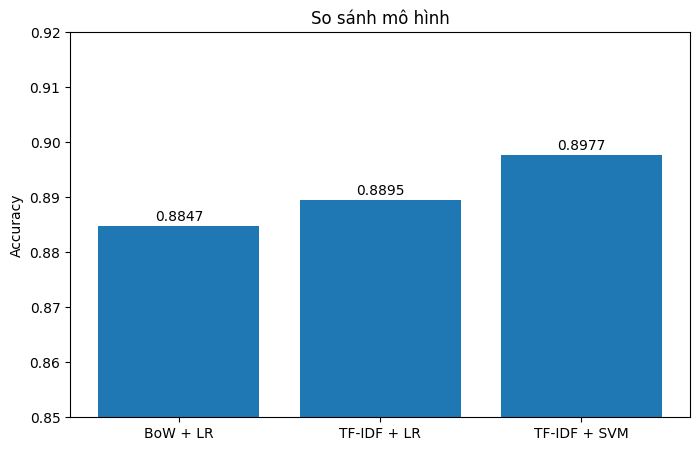

In [ ]:
import matplotlib.pyplot as plt

models = ['BoW + LR', 'TF-IDF + LR', 'TF-IDF + SVM']
scores = [acc_bow, acc_tfidf, acc_svm]

plt.figure(figsize=(8,5))
bars = plt.bar(models, scores)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.001,
             f'{height:.4f}',
             ha='center')

plt.ylim(0.85, 0.92)
plt.ylabel("Accuracy")
plt.title("So sánh mô hình")
plt.show()

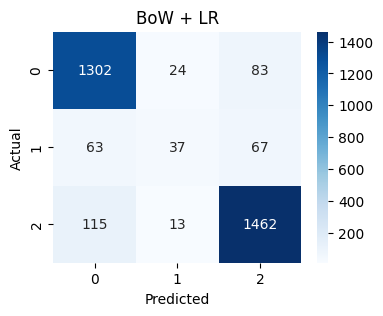

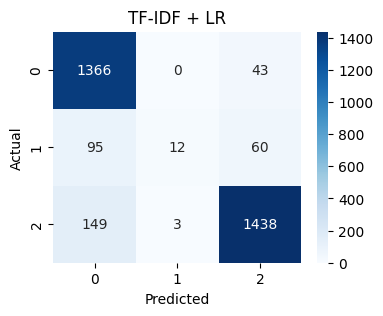

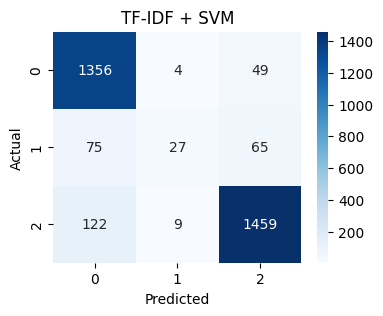

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(Y_test, y_pred_bow, "BoW + LR")
plot_cm(Y_test, y_pred_tfidf, "TF-IDF + LR")
plot_cm(Y_test, y_pred_svm, "TF-IDF + SVM")

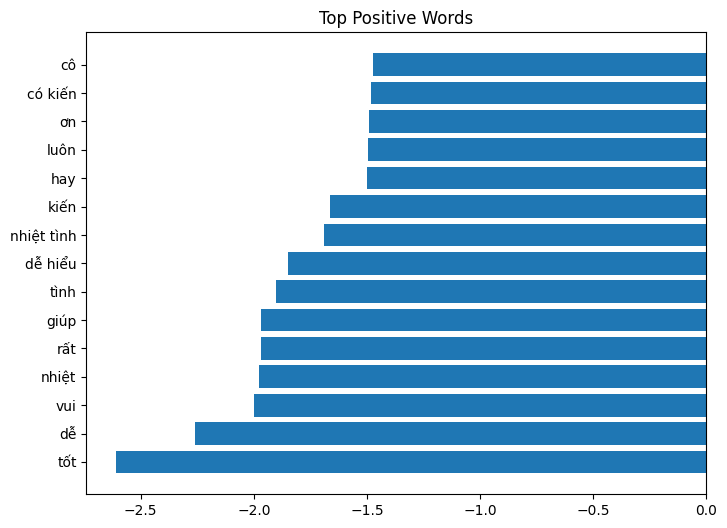

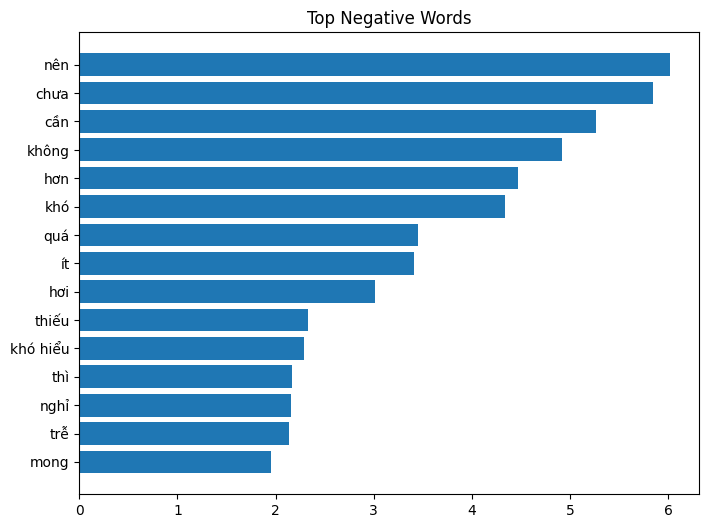

In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coef = model_tfidf.coef_[0]

top_negative_idx = coef.argsort()[-15:]
top_positive_idx = coef.argsort()[:15]

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_positive_idx], coef[top_positive_idx])
plt.title("Top Positive Words")
plt.show()

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_negative_idx], coef[top_negative_idx])
plt.title("Top Negative Words")
plt.show()

# Homework

1. Try the following and **observe the accuracy changes**:

    - Change:
      ```python
      ngram_range=(1,3)

    *   Remove Vietnamese stopwords
    *   Experiment with:
      
        ```python
          max_features = 5000

2. Try another model:
    *   Use Naive Bayes for sentiment classification.
    *   Error Analysis
        *   Print out 10 misclassified sentences
        *   Show the most important features (top weighted words)


3. Advance task

    *   Implement TF–IDF from scratch (USING FORMULAR)
    *   Compute TF, IDF
    *   Multiply them using the mathematical formula
    *   Using: TfidfVectorizer(analyzer='char', ngram_range=(3,5))
    *   Apply to another dataset
    *   Train and evaluate the model on a different dataset.
    *   Write a comparison report





4. Rebuild the Naive Bayes Model Using Advanced Techniques
    * Combine N-gram Features with TF–IDF: Use both **unigram + bigram** to capture more context
    * Cross-validation: Instead of using a single train/test split, use k-fold cross-validation
    * Hyperparameter Tuning with GridSearchCV: search for the best parameter combination automatically.
